In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load California Housing Dataset

data = fetch_california_housing()

X = data.data
y = data.target

In [3]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["Price"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

In [5]:
# KNN is distance-based, so scaling is required

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [6]:
# Create KNN Regressor

model = KNeighborsRegressor(

    n_neighbors=5
)

In [7]:
# KNN stores the training data

model.fit(

    X_train,

    y_train
)


KNeighborsRegressor()

In [8]:
y_pred = model.predict(X_test)

In [9]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R² :", r2)

MAE : 0.4461535271317829
MSE : 0.4324216146043236
RMSE : 0.6575877238850522
R² : 0.6700101862970989


In [11]:
results = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred

})

results.head(15)

,Actual,Predicted
0,0.47700,0.498800
1,0.45800,0.764600
2,5.00001,4.750006
3,2.18600,2.876600
4,2.78000,2.726200
5,1.58700,1.778600
6,1.98200,2.718200
7,1.57500,1.924600
8,3.40000,2.031400
9,4.46600,4.955608


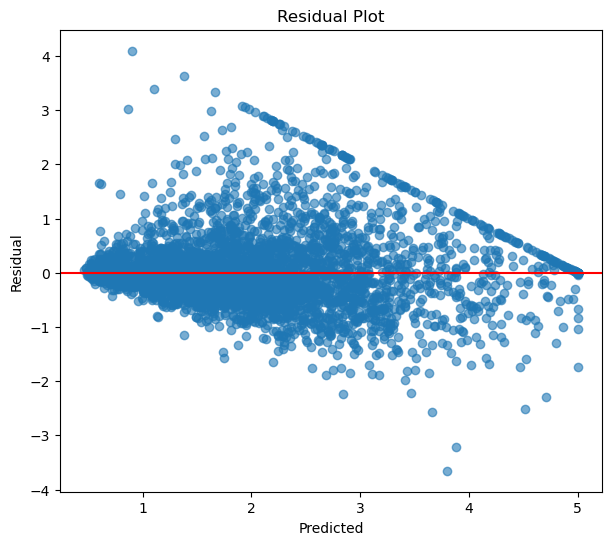

In [10]:
residual = y_test - y_pred

plt.figure(figsize=(7,6))

plt.scatter(

    y_pred,

    residual,

    alpha=0.6
)

plt.axhline(

    y=0,

    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

best value of k 

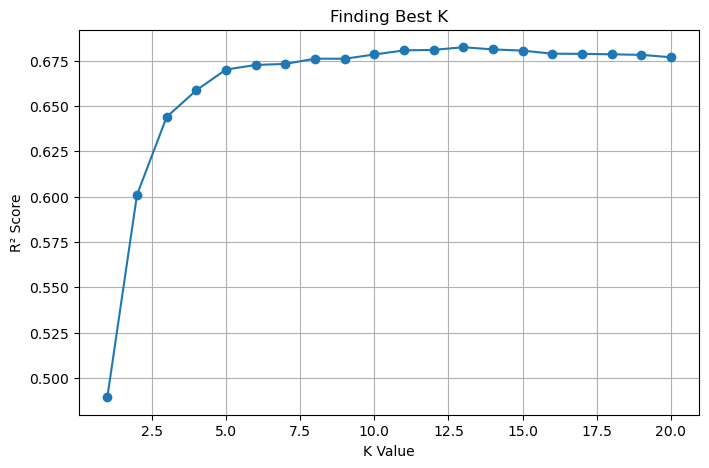

Best R² : 0.6823213122898445
Best K : 13


In [12]:
scores = []

for k in range(1,21):

    model = KNeighborsRegressor(n_neighbors=k)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    scores.append(r2_score(y_test, y_pred))

plt.figure(figsize=(8,5))

plt.plot(range(1,21), scores, marker="o")

plt.xlabel("K Value")

plt.ylabel("R² Score")

plt.title("Finding Best K")

plt.grid()

plt.show()

print("Best R² :", max(scores))
print("Best K :", scores.index(max(scores))+1)

Model : K-Nearest Neighbors Regressor

MAE  : Lower ✅

RMSE : Lower ✅

R²   : Higher ✅

Feature Scaling Required ✅

Best K found using validation.

Good for small and medium datasets.